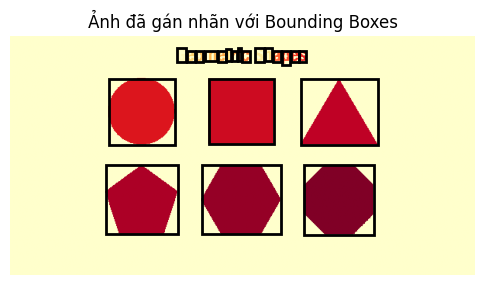

In [4]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

# B1: Đọc và chuyển ảnh sang grayscale
data = Image.open('geometric.png').convert('L')
a = np.asarray(data)

# B2: Ngưỡng Otsu
thres = threshold_otsu(a)

# B3: Tạo ảnh nhị phân
b = a > thres

# B4: Gán nhãn các vùng liên thông
c = label(b)

# B5: Lưu ảnh nhãn dưới dạng .png (không dùng jpg vì không hỗ trợ mode 'I')
iio.imwrite('label_output.png', c.astype(np.uint8))  # đổi sang uint8 nếu số nhãn < 256

# B6: Lấy thuộc tính các vùng
d = regionprops(c)

# B7: Hiển thị ảnh gán nhãn và vẽ BoundingBox
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(6, 6))
ax.imshow(c, cmap='YlOrRd')

# Vẽ các bounding boxes
for i in d:
    lr, lc, ur, uc = i['BoundingBox']
    rec_width = uc - lc
    rec_height = ur - lr
    rect = mpatches.Rectangle((lc, lr), rec_width, rec_height,
                              fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(rect)

plt.title("Ảnh đã gán nhãn với Bounding Boxes")
plt.axis('off')
plt.show()


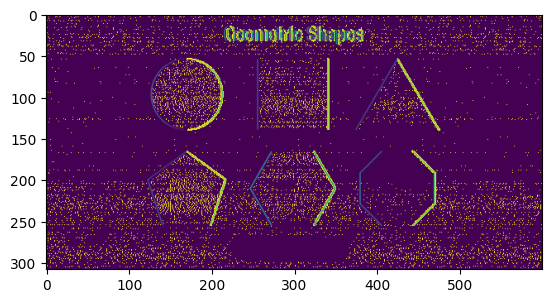

In [6]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png').convert('L')
bmg = abs(data - nd.shift(data,(0,1),order = 0))
plt.imshow(bmg)
plt.show()

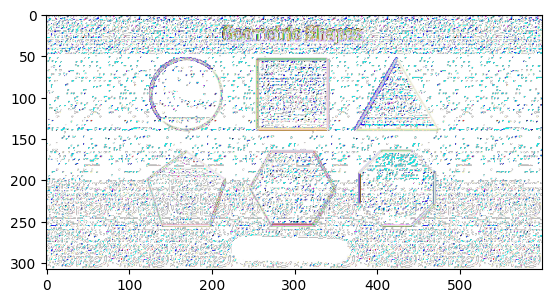

In [7]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

data = Image.open('geometric.png')
a = nd.sobel(data, axis = 0)
b = nd.sobel(data, axis = 1)
bmg = abs (a) + abs(b)
plt.imshow(bmg)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-49.800000000000004..255.0].


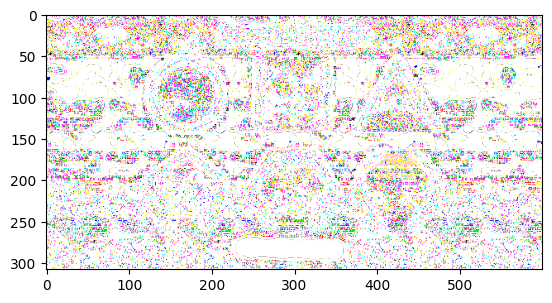

In [10]:
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def Harris(indata, alpha = 0.2):
    x = nd.sobel(indata, 0)
    y = nd.sobel(indata, 1)
    x1 = x **2
    y1 = y ** 2
    xy = abs(x * y)
    x1 = nd.gaussian_filter(x1,3)
    xy = nd.gaussian_filter(y1,3)
    x1 = nd.gaussian_filter(xy,3)

    detC = x1 * y1 -2 *xy
    trC = x1 + y1
    R = detC - alpha * trC**2
    return  R
data = Image.open('geometric.png')
bmg = Harris(data)
plt.imshow(bmg)
plt.show()
    


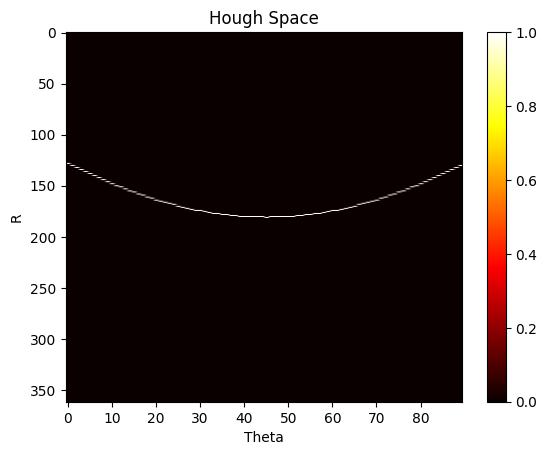

In [12]:
import cv2
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.filters.thresholding import threshold_otsu

def LineHough(data, gamma):
    V, H = data.shape
    R = int(np.sqrt(V * V + H * H))
    ho = np.zeros((R, 90), float)  # sửa lỗi thiếu dấu ngoặc
    w = data + 0
    ok = 1
    theta = np.arange(90) / 180.0 * np.pi
    tp = np.arange(90).astype(float)

    while ok:
        mx = w.max()
        if mx < gamma:         # sửa lỗi dùng nhầm 'nx'
            ok = 0
        else:
            v, h = divmod(w.argmax(), H)
            y = v              # sửa lại dòng này, V - V luôn = 0
            x = h
            rh = x * np.cos(theta) + y * np.sin(theta)
            for i in range(len(rh)):
                if 0 < rh[i] < R and 0 <= tp[i] < 90:
                    ho[int(rh[i]), int(tp[i])] += mx
            w[v, h] = 0        # sửa lỗi: đặt ngoài for để tiếp tục loop
    return ho                 # sửa lỗi: đưa return ra ngoài while

# Test với ảnh có 1 điểm sáng
data = np.zeros((256, 256))
data[128, 128] = 1

bmg = LineHough(data, 0.5)

plt.imshow(bmg, cmap='hot', aspect='auto')
plt.title("Hough Space")
plt.xlabel("Theta")
plt.ylabel("R")
plt.colorbar()
plt.show()


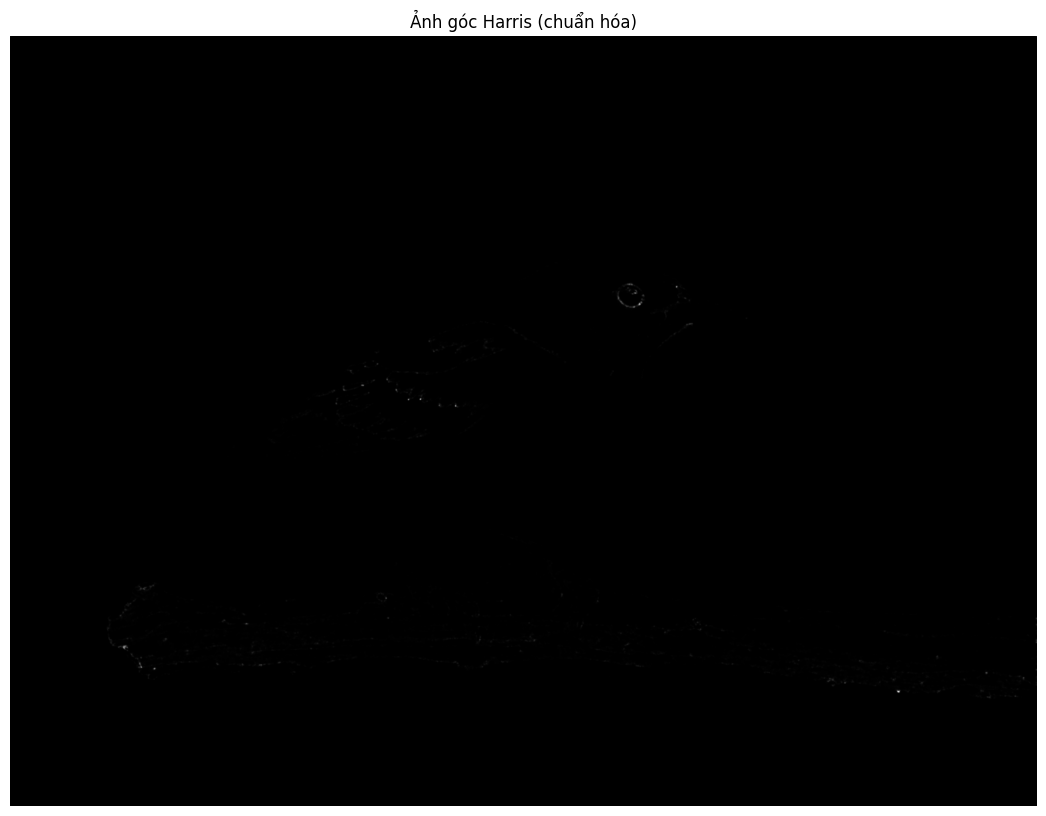

In [ ]:
from PIL import Image
import numpy as np
import cv2
import imageio.v2 as iio
import scipy.ndimage as nd
from skimage.morphology import label
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.color import rgb2gray
from skimage.feature import corner_harris 

data = iio.imread('bird.png')
Image_gray = rgb2gray(data)
coordinate = corner_harris(Image_gray,k = 0.001)

plt.figure(figsize=(20,10))
plt.imshow(coordinate)
plt.axis('off')
plt.show()